In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 시드 고정 (재현성)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
X_clf, y_clf = make_classification(
    n_samples=400, n_features=2, random_state=42,
    n_informative=2, n_redundant=0,n_clusters_per_class=1,class_sep=1.5
    )
scaler = StandardScaler()
# 데이터 분할 train - test 8:2
x_train,x_test,y_train,y_test = train_test_split(X_clf,y_clf,random_state=42, stratify=y_clf,test_size=0.2)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
# pytorch 텐서로 변환
X_clf_train_tensor = torch.tensor(x_train,dtype=torch.float32)
y_clf_train_tensor = torch.FloatTensor(y_train)
x_test_tensor = torch.FloatTensor(x_test)
y_test_tensor = torch.FloatTensor(y_test)

In [3]:
# 분류모델 정의
class BinaryClassifier(nn.Module):
  def __init__(self,input_dim, hidden_dim) -> None:
    super().__init__()
    self.fc1 = nn.Linear( input_dim , hidden_dim)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_dim ,1 )
  def forward(self, x):
    x = self.relu( self.fc1(x) )
    output = self.fc2(x)
    return output
model_clf = BinaryClassifier(2,16)
model_clf

BinaryClassifier(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

100%|██████████| 100/100 [00:01<00:00, 93.14it/s]


[11.140664875507355,
 7.87850895524025,
 5.594776958227158,
 4.270726054906845,
 3.547458991408348,
 3.0930248014628887,
 2.8120378740131855,
 2.6345986239612103,
 2.4934272691607475,
 2.384165709838271,
 2.2993583790957928,
 2.244812486693263,
 2.1827042028307915,
 2.1485282573848963,
 2.1005490757524967,
 2.0762121565639973,
 2.0453403908759356,
 2.0172637198120356,
 2.0007279235869646,
 1.9770855847746134,
 1.9831269946880639,
 1.9706301214173436,
 1.9319821950048208,
 1.9305313006043434,
 1.9101851806044579,
 1.8968074955046177,
 1.8858394157141447,
 1.8889812994748354,
 1.8645420223474503,
 1.865702610462904,
 1.8553217127919197,
 1.8442901563830674,
 1.8439127835445106,
 1.8310324996709824,
 1.8145499611273408,
 1.8120484882965684,
 1.819708205293864,
 1.8191292425617576,
 1.792061003856361,
 1.7897692462429404,
 1.7868638117797673,
 1.782938251271844,
 1.7917815996333957,
 1.7704464197158813,
 1.7651426820084453,
 1.7652919767424464,
 1.7673738384619355,
 1.7559467889368534,
 1.

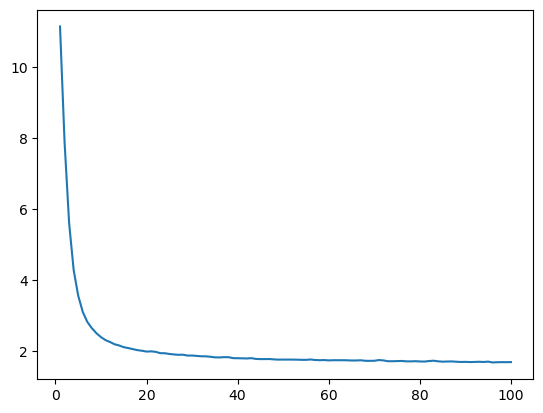

In [5]:

from tqdm import tqdm
model_clf = BinaryClassifier(2,16)
criterion = nn.BCEWithLogitsLoss()
optimizer_momentum = optim.SGD(model_clf.parameters(), lr=0.01, momentum=0.9)

x_train_dataset = TensorDataset(X_clf_train_tensor,y_clf_train_tensor)
x_train_loader = DataLoader(x_train_dataset,batch_size=16,shuffle=True)
# 훈련루프
epochs = 100
epoch_losses = []
for epoch in tqdm(range(epochs)):
  epoch_loss = 0
  for data, label in x_train_loader:
    optimizer_momentum.zero_grad();
    predict = model_clf(data).squeeze(1)
    loss = criterion(predict, label)
    loss.backward()
    optimizer_momentum.step()

    epoch_loss +=  loss.item()
  epoch_loss / len(x_train_loader)
  epoch_losses.append(epoch_loss)

# loss값들을 저장해서 시각화 vs sgd
plt.plot(range(1,epochs+1),epoch_losses )
epoch_losses